<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/07_2_%ED%85%8D%EC%8A%A4%ED%8A%B8_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%8B%A4%EB%A3%A8%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## 01 예제 애플리케이션: 영화 리뷰 감성 분석
- 데이터셋: 1-10점 중 7점 이상은 "양성", 4점 이하는 "음성"인 이진 분류 데이터 (중간은 포함하지 않음)

In [3]:
# 데이터 다운
!wget -nc http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz -P data
!tar xzf data/aclImdb_v1.tar.gz --skip-old-files -C data

File ‘data/aclImdb_v1.tar.gz’ already there; not retrieving.



In [4]:
!find ./data -type d

./data
./data/aclImdb
./data/aclImdb/test
./data/aclImdb/test/neg
./data/aclImdb/test/pos
./data/aclImdb/train
./data/aclImdb/train/neg
./data/aclImdb/train/unsup
./data/aclImdb/train/pos


In [5]:
# 사용하지 않는 폴더 삭제
!rm -r data/aclImdb/train/unsup
!find ./data -type d

./data
./data/aclImdb
./data/aclImdb/test
./data/aclImdb/test/neg
./data/aclImdb/test/pos
./data/aclImdb/train
./data/aclImdb/train/neg
./data/aclImdb/train/pos


In [6]:
from sklearn.datasets import load_files

reviews_train = load_files("data/aclImdb/train/")
text_train, y_train = reviews_train.data, reviews_train.target
print(f"text_train의 타입: {type(text_train)}")
print(f"text_train의 길이: {len(text_train)}")
print(f"text_train[6]:\n{text_train[6]}")

text_train의 타입: <class 'list'>
text_train의 길이: 25000
text_train[6]:
b"This movie has a special way of telling the story, at first i found it rather odd as it jumped through time and I had no idea whats happening.<br /><br />Anyway the story line was although simple, but still very real and touching. You met someone the first time, you fell in love completely, but broke up at last and promoted a deadly agony. Who hasn't go through this? but we will never forget this kind of pain in our life. <br /><br />I would say i am rather touched as two actor has shown great performance in showing the love between the characters. I just wish that the story could be a happy ending."


In [7]:
# HTML 태그 삭제
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

In [8]:
# 같은 비율의 양성과 음성 레이블
print(f"클래스별 샘플 수 (훈련 데이터): {np.bincount(y_train)}")

클래스별 샘플 수 (훈련 데이터): [12500 12500]


In [9]:
reviews_test = load_files("data/aclImdb/test/")
text_test, y_test = reviews_test.data, reviews_test.target
print(f"테스트 데이터의 문서 수: {len(text_test)}")
print(f"클래스별 샘플 수 (테스트 데이터): {np.bincount(y_test)}")
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

테스트 데이터의 문서 수: 25000
클래스별 샘플 수 (테스트 데이터): [12500 12500]


## 02 텍스트 데이터를 BOW로 표현하기
- BOW(bag of words)
  - 가장 간단하지만 효과적이면서 널리 쓰이는 방법
  - 장, 문단, 문장, 서식 같은 입력 텍스트의 구조 대부분을 잃고, 각 단어가 이 말뭉치에 있는 텍스트에 얼마나 많이 나타나는지만 헤아림
  - 구조와 상관없이 단어의 출현 횟수만 셈
- BOW의 단계
  1. 토큰화(tokenization): 각 문서를 문서에 담긴 단어(토큰)로 나눔. 예를 들어 공백이나 구두점을 기준으로 분리
  2. 어휘 사전 구축: 모든 문서에 나타난 모든 단어의 어휘를 모으고 번호를 매김 (알파벳 순서)
  3. 인코딩: 어휘 사전의 단어가 문서마다 몇 번이나 나타나는지를 헤아림
- 출력은 각 문서에 나타난 단어의 횟수가 담긴 하나의 벡터

### 2.1 샘플 데이터에 BOW 적용하기

In [10]:
# 데이터 준비
bards_words = ["The fool doth think he is wise",
               "but the wise man knows himself to be a fool"]

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

In [12]:
# CountVectorizer.fit(): 토큰으로 나누고 어휘 사전을 구축
print(f"어휘 사전의 크기: {len(vect.vocabulary_)}")
print(f"어휘 사전의 내용:\n{vect.vocabulary_}")

어휘 사전의 크기: 13
어휘 사전의 내용:
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [13]:
# CountVectorizer.transform(): BOW 표현을 만듦
bag_of_words = vect.transform(bards_words)
print(f"BOW: {repr(bag_of_words)}")

BOW: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


- BOW 표현은 0이 아닌 값만 저장하는 희소 행렬로 저장 (특성 배열의 대부분의 원소가 0이라서 희소 행렬을 사용)
- 각각의 행은 하나의 데이터 포인트, 각 특성은 어휘 사전에 있는 각 단어에 대응

In [14]:
print(f"BOW의 밀집 표현:\n{bag_of_words.toarray()}")

BOW의 밀집 표현:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


- 각 단어의 출현 횟수는 0아니면 1
- 👉 두 문자열 모두 같은 단어를 두 개 이상 가지고 있지 않음
- 첫 번째 문자열 `The fool doth think he is wise`는 첫 번째 행으로 나타나며, 어휘 사전의 첫 번째 단어 `be`가 0번 나옴, 세 번째 단어 `doth`는 1번 나옴

### 2.2 영화 리뷰에 대한 BOW

In [15]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train:\n{repr(X_train)}")

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


In [16]:
feature_names = vect.get_feature_names_out()
print(f"특성 개수:{len(feature_names)}")
print(f"처음 20개 특성:\n{feature_names[:20]}")
print(f"20010에서 20030까지 특성:\n{feature_names[20010:20030]}")
print(f"매 2000번째 특성:\n{feature_names[::2000]}")

특성 개수:74849
처음 20개 특성:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
20010에서 20030까지 특성:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
매 2000번째 특성:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


- 희소 행렬의 고차원 데이터셋에서는 `LogisticRegression`같은 선형 모델의 성능이 가장 뛰어남

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=1000), X_train, y_train,
                         n_jobs=-1)
print(f"교차 검증 평균 점수: {round(np.mean(scores), 2)}")

교차 검증 평균 점수: 0.88


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")
print(f"최적의 매개변수: {grid.best_params_}")

최상의 교차 검증 점수: 0.89
최적의 매개변수: {'C': 0.1}


In [19]:
X_test = vect.transform(text_test)
print(f"테스트 점수: {round(grid.score(X_test, y_test), 2)}")

테스트 점수: 0.88


#### 2.2.1 단어 추출 방법 개선
- 숫자 같은 의미 없는 특성이 생성되는 것을 줄이는 방법: 적어도 두 개의 문서 (또는 다섯 개의 문서 등)에 나타난 토큰만을 사용

In [20]:
# min_df 매개변수로 토큰이 나타날 최소 문서 개수 지정
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print(f"min_df로 제한한 X_train: {repr(X_train)}")

min_df로 제한한 X_train: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


In [21]:
feature_names = vect.get_feature_names_out()

print(f"처음 50개 특성:\n{feature_names[:50]}")
print(f"20010부터 20030까지 특성:\n{feature_names[20010:20030]}")
print(f"매 700번째 특성:\n{feature_names[::700]}")

처음 50개 특성:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
20010부터 20030까지 특성:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
매 700번째 특성:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 'tvs' 'vampyre' 'western

In [22]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.89


- 모델 성능은 높아지지 않았지만 특성의 개수가 줄어서 처리 속도가 빨라지고, 불필요한 특성이 없어져 모델을 이해하기 쉬워짐

## 03 불용어
- 의미 없는 단어를 제거하는 또 다른 방법: 너무 빈번하여 유용하지 않은 단어를 제거
- 1️⃣ 언어별 불용어 목록을 사용
- 2️⃣ 너무 자주 나타나는 단어를 제거
- `sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`: 영어의 불용어

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(f"불용어 개수: {len(ENGLISH_STOP_WORDS)}")
print(f"매 10번째 불용어:\n{list(ENGLISH_STOP_WORDS)[::10]}")

불용어 개수: 318
매 10번째 불용어:
['nor', 'me', 'thick', 'however', 'here', 'something', 'much', 'wherever', 'cannot', 'the', 'everything', 'where', 'anyhow', 'seems', 'are', 'cry', 'thence', 'ever', 'through', 'have', 'afterwards', 'fire', 'co', 'should', 'and', 'hence', 'around', 'next', 'eg', 'less', 'below', 'back']


In [24]:
#stop_words="english": 내장된 불용어 사용

vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print(f"불용어가 제거된 X_train:\n{repr(X_train)}")

불용어가 제거된 X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


In [25]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.88


- 👉 모델 해석이 나아지지 않았으므로 불용어 목록을 사용하는 것이 도움이 되지 않음
- 고정된 불용어 목록은 모델이 데이터셋만 보고 불용어를 골라내기 어려운 작은 데이터셋에서 동무이 됨

## 04 tf-idf로 데이터 스케일 변경하기
- 얼마나 의미 있는 특성인지를 계산해서 스케일을 조정하는 방식
- tf-idf
  - 말뭉치의 다른 문서보다 특성 문서에서 자주 나타나는 단어에 높은 가중치를 주는 방법
  - 한 단어가 특정 문서에 자주 나타나고 다른 여러 문서에서는 그렇지 않다면, 그 문서의 내용을 아주 잘 설명하는 단어라고 봄

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, n_jobs=-1)
grid.fit(text_train, y_train)
print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")

최상의 교차 검증 점수: 0.89


- 👉 tf-idf가 성능에 큰 영향을 주지 못함
- tf-idf는 어떤 단어가 가장 중요한지도 알려줌
- 문서를 구별하는 단어를 찾는 방법이지만 완전히 비지도 학습 ➡️ '긍정적인 리뷰'와 '부정적인 리뷰' 레이블과 꼭 관계있지 않음!

In [27]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]

# 훈련 데이터셋을 변환
X_train = vectorizer.transform(text_train)

# 특성 별로 가장 큰 값을 찾음
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()

# 특성 이름 구하기
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"가장 낮은 tfidf를 가진 특성:\n{feature_names[sorted_by_tfidf[:20]]}")
print(f"가장 높은 tfidf를 가진 특성:\n{feature_names[sorted_by_tfidf[-20:]]}")

가장 낮은 tfidf를 가진 특성:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
가장 높은 tfidf를 가진 특성:
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


- tf-idf가 낮은 특성은 전체 문서에 걸쳐 매우 많이 나타나거나, 조금씩만 사용되거나, 매우 긴 문서에서만 사용됨
- tf-idf가 높은 특성은 특정한 쇼나 드라마에 대한 리뷰 등 특정 리뷰에서 매우 자주 나타남

In [28]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print(f"가장 낮은 idf를 가진 특성:\n {feature_names[sorted_by_idf[:100]]}")

가장 낮은 idf를 가진 특성:
 ['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


## 05 모델 계수 조사


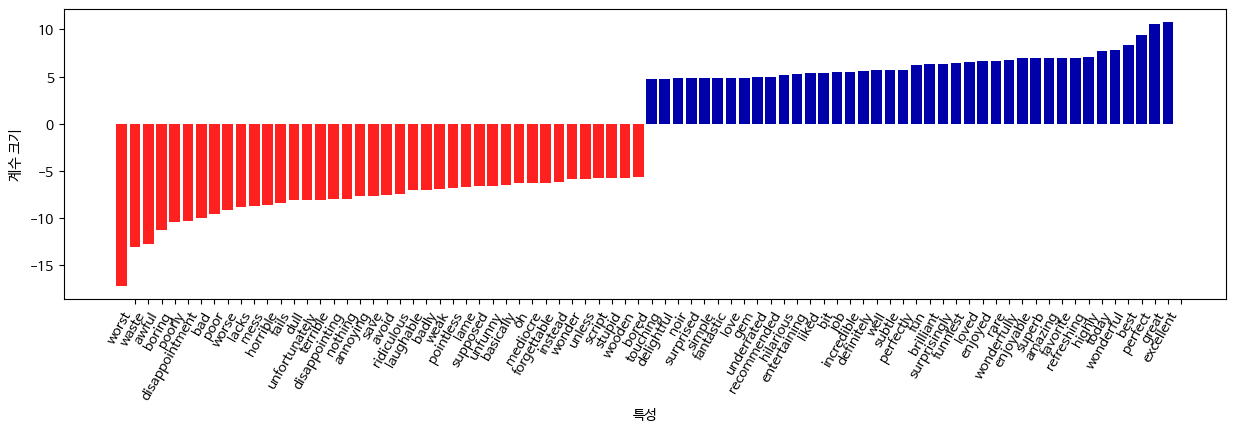

In [29]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_[0],
    feature_names, n_top_features=40
)

- 왼쪽의 음수 계수는 모델에서 부정적인 리뷰를 의미하는 단어에 속하고, 오른쪽 양수 계수는 긍정적인 리뷰의 단어에 해당
- 대부분의 단어는 매우 직관적

## 06 여러 단어로 만든 BOW(n-그램)
- BOW의 단점: 단어의 순서가 무시됨
- BOW 표현 방식을 사용할 때 문맥을 고려하는 방법: 토큰 하나의 횟수만 고려하지 않고 옆에 있는 두 세개의 토큰을 함께 고려하는 방식
- 토큰 두 개를 **바이그램**(bigram), 세 개를 **트라이그램**(trigram), 일반적으로 연속된 토큰을 **n-그램**(n-gram)이라고 함
- `ngram_range` 매개변수
  - 특성으로 고려할 토큰의 범위를 지정
  - 연속된 토큰의 최소 길이와 최대 길이

In [30]:
print(f"bards_words:\n{bards_words}")

bards_words:
['The fool doth think he is wise', 'but the wise man knows himself to be a fool']


In [31]:
# 유니그램: 최소 길이가 1이고 최대 길이가 1인 토큰마다 하나의 특성
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print(f"어휘 사전 크기: {len(cv.vocabulary_)}")
print(f"어휘 사전:\n{cv.get_feature_names_out()}")

어휘 사전 크기: 13
어휘 사전:
['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']


In [32]:
# 바이그램: 토큰 두 개가 연속
cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print(f"어휘 사전 크기: {len(cv.vocabulary_)}")
print(f"어휘 사전:\n{cv.get_feature_names_out()}")

어휘 사전 크기: 14
어휘 사전:
['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


In [33]:
print(f"변환된 데이터 (밀집 배열):\n{cv.transform(bards_words).toarray()}")

변환된 데이터 (밀집 배열):
[[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


- 👉 `bard_words`에 있는 두 문장 사이에는 공통된 바이그램이 없음
- 단어 하나가 큰 의미가 가진 경우가 많으므로 대부분의 애플리케이션에서 토큰의 최소 길이는 1
- 많은 경우에 바이그램을 추가하면 도움이 됨
- 최대 5-그램까지는 도움이 되지만, 과대적합될 가능성이 있음

In [34]:
# bards_words에 유니그램, 바이그램, 트라이그램 적용
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print(f"어휘 사전 크기: {len(cv.vocabulary_)}")
print(f"어휘 사전:\n{cv.get_feature_names_out()}")

어휘 사전 크기: 39
어휘 사전:
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


In [35]:
# IMDb 데이터에 TfidVectorizer를 적용하고 그리드 서치로 최적의 n-그램 범위 찾기

pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))

param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, n_jobs=-1)
grid.fit(text_train, y_train)

print(f"최상의 교차 검증 점수: {round(grid.best_score_, 2)}")
print(f"최적의 매개변수:\n{grid.best_params_}")

최상의 교차 검증 점수: 0.91
최적의 매개변수:
{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 3)}


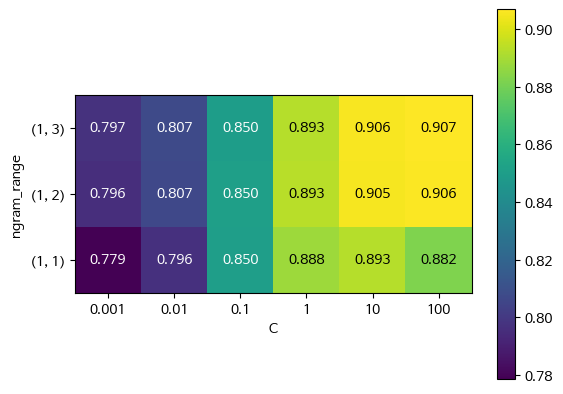

In [37]:
# 매개변수 ngram_range와 C에 대한 평균 교차 검증 정확도의 히트맵

scores = grid.cv_results_["mean_test_score"].reshape(-1, 3).T

heatmap = mglearn.tools.heatmap(
    scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f",
    xticklabels=param_grid["logisticregression__C"],
    yticklabels=param_grid["tfidfvectorizer__ngram_range"]
)
plt.colorbar(heatmap)
plt.show()

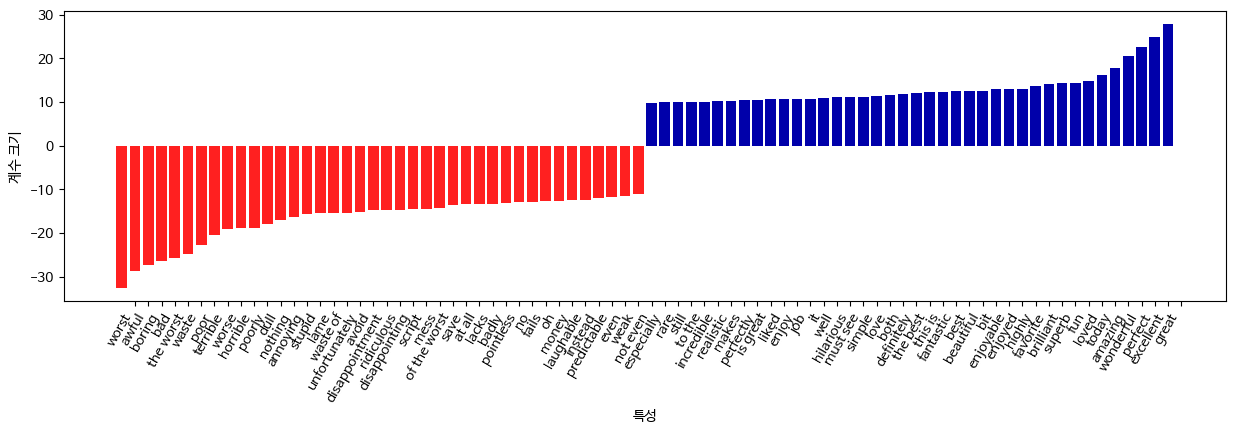

In [38]:
# tf-idf와 유니그램, 바이그램, 트라이그램을 사용한 모델에서 가장 중요한 특성

vect = grid.best_estimator_.named_steps["tfidfvectorizer"]
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps["logisticregression"].coef_

mglearn.tools.visualize_coefficients(coef[0], feature_names, n_top_features=40)

- `worth`: 문맥이 단어의 의미에 영향을 줌

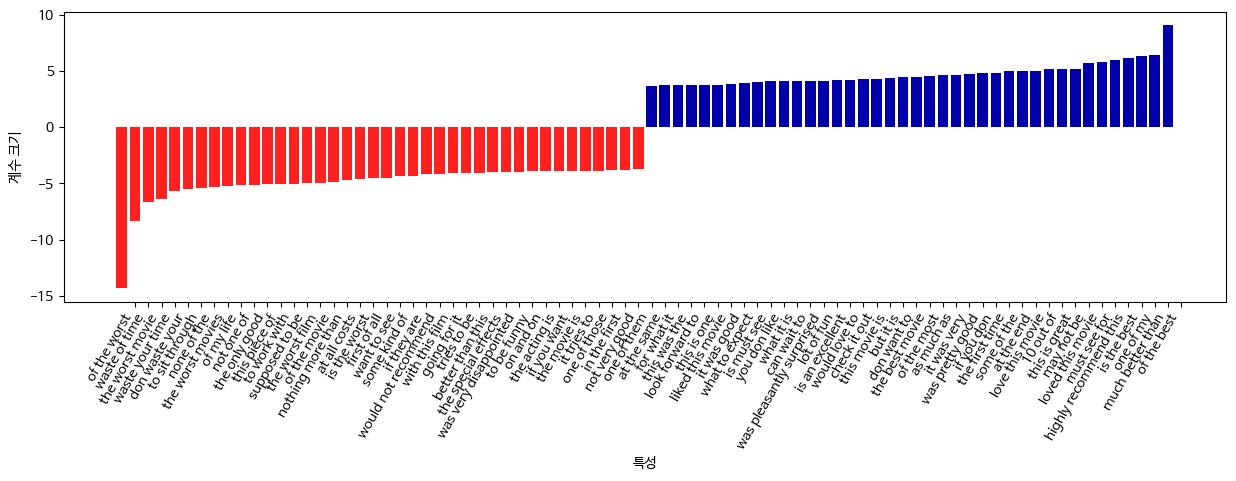

In [39]:
# 모델의 트라이그램 중요도를 나타낸 그래프

mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3

mglearn.tools.visualize_coefficients(coef.ravel()[mask],
                                     feature_names[mask], n_top_features=40)

- 👉 영향력이 큰 바이그램과 트라이그램의 대부분은 독립적일 땐 큰 의미가 없는 단어들로 구성
- 👉 하지만 이러한 특성으로 인한 영향은 유니그램의 중요도와 비교했을 때 상당히 제한적

## 07 고급 토큰화, 어간 추출, 표제어 추출
- 명사의 단수형과 복수형, 여러 동사형과 관련 단어들을 다른 토큰으로 다루면 모델의 과대적합 위험성이 높음
- 이 문제를 해결하기 위해서는 각 단어를 그 단어의 어간으로 표현해서 같은 어간을 가진 모든 단어를 구분해야 (또는 합쳐야) 함
- **어간 추출**(stemming): 일일이 어미를 찾아 제외하는 규칙 기반 방식
- **표제어 추출**(lemmatization):알려진 단어의 형태 사전을 사용하고 문장에서 단어의 역할을 고려하는 처리 방식
- 어간 추출과 표제어 추출 방식은 단어의 일반 형태를 추출하는 **정규화**의 한 형태


In [41]:
# spacy의 영어 모듈 다운
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [42]:
import spacy
import nltk

# spacy의 영어 모델 로드
en_nlp = spacy.load("en_core_web_sm")
# nltk의 PorterStemmer 객체 생성
stemmer = nltk.stem.PorterStemmer()

# spacy의 표제어 추출과 nltk의 어간 추출을 비교하는 함수
def compare_normalization(doc):
  # spacy로 문서를 토큰화
  doc_spacy = en_nlp(doc)
  # spacy로 찾은 표제어 출력
  print(f"표제어:\n{[token.lemma_ for token in doc_spacy]}")
  # PorterStemmer로 찾은 토큰 출력
  print(f"어간:\n{[stemmer.stem(token.norm_.lower()) for token in doc_spacy]}")

In [44]:
# 표제어 추출과 Porter 어간 추출기의 차이 비교
compare_normalization(u"Our meeting today was worse than yesterday, "
"I'm scared of meeting the clients tomorrow.")

표제어:
['our', 'meeting', 'today', 'be', 'bad', 'than', 'yesterday', ',', 'I', 'be', 'scared', 'of', 'meet', 'the', 'client', 'tomorrow', '.']
어간:
['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday', ',', 'i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow', '.']


- 👉 표제어 추출이 어간 추출보다 더 복잡한 처리를 거치지만, 머신러닝을 위해 토큰 정규화를 할 때는 어간 추출보다 더 좋은 결과

In [45]:
# spacy의 언어 모델 로드
en_nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# 표제어 추출을 사용하여 표제어 리스트로 변환
def custom_tokenizer(document):
  doc_spacy = en_nlp(document)
  return [token.lemma_ for token in doc_spacy]

lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, min_df=5)

In [46]:
X_train_lemma = lemma_vect.fit_transform(text_train)
print(f"X_train_lemma.shape: {X_train_lemma.shape}")

# 비교를 위한 표준 CountVectorizer
X_train = CountVectorizer(min_df=5).fit_transform(text_train)
print(f"X_train.shape: {X_train.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


X_train_lemma.shape: (25000, 21897)
X_train.shape: (25000, 27271)


In [47]:
from sklearn.model_selection import StratifiedShuffleSplit

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.99,
                            train_size=0.01, random_state=0)
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=cv, n_jobs=-1)

# 기존 CountVectorizer로 그리드 서치 수행
grid.fit(X_train, y_train)
print(f"최상의 교차 검증 점수 (기본 CountVectorizer): {round(grid.best_score_, 3)}")

# 표제어를 사용한 그리드 서치
grid.fit(X_train_lemma, y_train)
print(f"최상의 교차 검증 점수 (표제어): {round(grid.best_score_, 3)}")

최상의 교차 검증 점수 (기본 CountVectorizer): 0.719
최상의 교차 검증 점수 (표제어): 0.719


### 7.1 KoNLPy를 사용한 영화 리뷰 분석

In [48]:
!pip install konlpy JPype1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 33.4 MB/s eta 0:00:00


In [49]:
# ratings_train.txt 다운로드
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

# ratings_test.txt 다운로드
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

--2026-01-10 11:58:21--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  56.5MB/s    in 0.2s    

2026-01-10 11:58:22 (56.5 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-01-10 11:58:22--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet

In [50]:
# 훈련 데이터 로드

df_train = pd.read_csv("ratings_train.txt", delimiter='\t',
                       keep_default_na=False)
df_train.head(n=3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [51]:
text_train, y_train = df_train["document"].values, df_train["label"].values

In [53]:
# 테스트 데이터 로드

df_test = pd.read_csv("ratings_test.txt", delimiter='\t',
                      keep_default_na=False)
text_test, y_test =  df_test["document"].values, df_test["label"].values

In [54]:
print(f"훈련 데이터 길이: {len(text_train)}, 클래스 비율: {np.bincount(y_train)}")
print(f"테스트 데이터 길이: {len(text_test)}, 클래스 비율: {np.bincount(y_test)}")

훈련 데이터 길이: 150000, 클래스 비율: [75173 74827]
테스트 데이터 길이: 50000, 클래스 비율: [24827 25173]


In [61]:
from konlpy.tag import Okt

class PicklableOkt(Okt):
  def __init__(self, *args):
    self.args = args
    Okt.__init__(self, *args)

  def __setstate__(self, state):
    self.__init__(*state['args'])

  def __getstate__(self):
    return {"args": self.args}

okt = PicklableOkt()

In [64]:
param_grid = {"tfidfvectorizer__min_df": [3, 5, 7],
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)],
              "logisticregression__C": [0.1, 1, 10]}

# okt.morphs: 형태소 분석 메서드
pipe = make_pipeline(TfidfVectorizer(tokenizer=okt.morphs, token_pattern=None),
                     LogisticRegression())
grid = GridSearchCV(pipe, param_grid)

# 1000개 샘플만 사용
grid.fit(text_train[:1000], y_train[:1000])

print(f"최상의 교차 검증 점수: {round(grid.best_score_, 3)}")
print(f"최적의 교차 검증 매개변수: {grid.best_params_}")

최상의 교차 검증 점수: 0.718
최적의 교차 검증 매개변수: {'logisticregression__C': 1, 'tfidfvectorizer__min_df': 3, 'tfidfvectorizer__ngram_range': (1, 3)}


In [65]:
tfidfvectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
X_test = tfidfvectorizer.transform(text_test[:1000])
logisticregression = grid.best_estimator_.named_steps["logisticregression"]
score = logisticregression.score(X_test, y_test[:1000])
print(f"테스트 세트 점수: {round(score, 3)}")

테스트 세트 점수: 0.713


## 08 토픽 모델링과 문서 군집화
- **토픽 모델링**(topic modeling): 비지도학습으로 문서를 하나 또는 그 이상의 토픽으로 할당하는 작업을 통칭
- 학습된 각 성분은 하나의 토픽에 해당하며 문서를 표현한 성분의 계수는 문서가 어떤 토픽에 얼마만큼 연관되어 있는지를 말해줌

### 8.1 LDA
- 잠재 디리클레 할당 (Latent Dirichlet Allocation; LDA)
- 성분 분해 방법
- 함께 자주 나타나는 단어의 그룹(토픽)을 찾는 것: 토픽은 일반적으로 말하는 '주제'가 아니고, 의미가 있든 없든 PCA나 NMF로 추출한 성분에 가까운 것
- 각 문서에 토픽의 일부가 혼합되어 이싿고 간주

In [72]:
# 데이터 로드
reviews_train = load_files("data/aclImdb/train/")
text_train, y_train = reviews_train.data, reviews_train.target

In [73]:
# 15%의 문서에서 나타나는 단어 삭제 후 가장 많이 등장하는 단어 10000개에 대해 BOW

vect = CountVectorizer(max_features=10000, max_df=.15)
X = vect.fit_transform(text_train)

In [74]:
# 10개의 토픽으로 토픽 모델 학습
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10, learning_method="batch",
                                max_iter=25, random_state=0, n_jobs=-1)
document_topics = lda.fit_transform(X)

In [75]:
# components_: (n_topics, n_words) 토픽마다 각 단어의 중요도를 저장
print(f"lda.components_.shape: {lda.components_.shape}")

lda.components_.shape: (10, 10000)


In [77]:
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())

mglearn.tools.print_topics(topics=range(10), feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=10)

topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
role          action        young         horror        murder        
performance   original      town          gore          thriller      
cast          effects       old           effects       police        
actor         animation     later         dead          killer        
actors        series        gets          around        director      
director      game          john          blood         wife          
performances  fight         father        gets          woman         
play          special       woman         pretty        horror        
work          fun           years         killer        crime         
john          new           wife          scary         interesting   


topic 5       topic 6       topic 7       topic 8       topic 9       
--------      --------      --------      --------      --------      
worl

In [81]:
# 100개의 토픽 학습
lda100 = LatentDirichletAllocation(n_components=100, learning_method="batch",
                                max_iter=25, random_state=0, n_jobs=-1)
document_topics100 = lda100.fit_transform(X)

In [82]:
topics = np.array([7, 16, 24, 28, 36, 37, 41, 45, 51, 53, 54, 63, 89, 97])

sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())

mglearn.tools.print_topics(topics=topics, feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=20)

topic 7       topic 16      topic 24      topic 28      topic 36      
--------      --------      --------      --------      --------      
jane          star          christian     stories       moon          
tarzan        stewart       jesus         paris         evil          
jungle        town          god           new           duke          
rochester     luke          christ        city          ice           
bo            new           football      each          our           
modesty       jimmy         larry         between       versus        
derek         wars          bible         different     holmes        
eyre          city          big           french        cream         
novel         lucas         tracy         couple        find          
dalton        sheriff       madonna       york          poison        
timothy       emperor       stooges       though        dukes         
version       mayor         church        find          daisy         
mate  

In [84]:
# 좀비 관련 내용인 토픽 89
zombie = np.argsort(document_topics100[:, 89])[::-1]

for i in zombie[:10]:
  print(b".".join(text_train[i].split(b".")[:2]) + b".\n")

b'Goodnight, Mister Tom begins in an impossibly exquisite village in the south of England where the sun always seems to shine. Before we have much idea of the period we hear a radio announcement of the declaration of World War II.\n'
b'Goodnight, Mister Tom begins in an impossibly exquisite village in the south of England where the sun always seems to shine. Before we have much idea of the period we hear a radio announcement of the declaration of World War II.\n'
b'Due to the invention of a "The Domestication Collar", flesh-eating zombies are brought under control, and become productive members of society; however, they perform menial tasks. The servile dead attend to those living in fenced US 1950s-styled small towns, while untamed zombies roam around in "The Wild Zone".\n'
b"I thought that Zombie Flesh Eaters 2 was quite a good horror film When a terrorist's body, infected with a stolen chemical, is recovered by the US military, the corpse is then cremated, releasing the virus into t

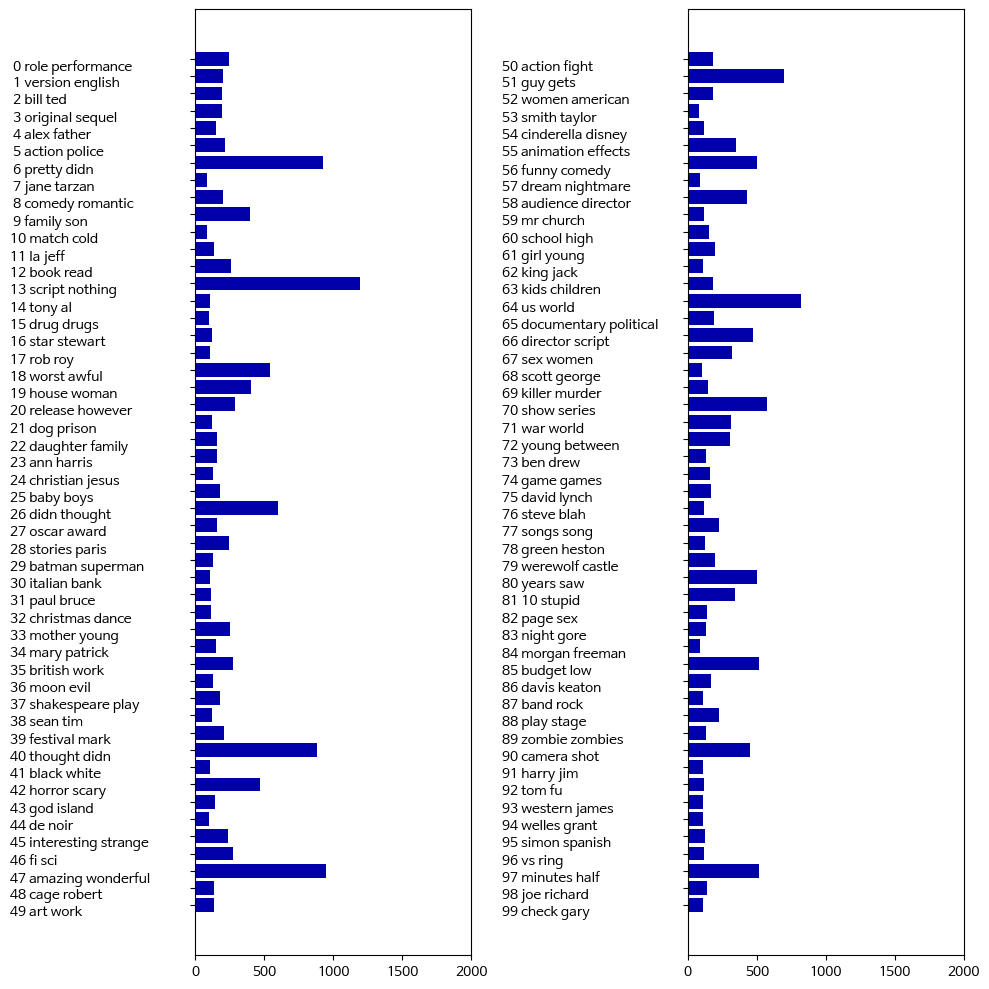

In [86]:
# LDA로 학습한 토픽 가중치
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
topic_names = [f"{i:>2} {' '.join(words)}" for i, words in enumerate(feature_names[sorting[:, :2]])]

for col in [0, 1]:
  start = col * 50
  end = (col + 1) * 50
  ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
  ax[col].set_yticks(np.arange(50))
  ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
  ax[col].invert_yaxis()
  ax[col].set_xlim(0, 2000)
  yax = ax[col].get_yaxis()
  yax.set_tick_params(pad=130)

plt.tight_layout()
plt.show()

- 토픽 모델은 레이블이 없거나, 레이블이 있더라도 큰 규모의 텍스트 말뭉치를 해석하는 데 좋은 방법
- 확률적 알고리즘이므로 `random_state`를 바꾸면 결과가 많이 달라짐
- 비지도 학습에서 내린 결론은 보수적으로 평가해야 하므로 각 토픽에 해당하는 문서를 직접 보고 직관을 검증하는 것이 좋음
- `LDA.transform()`에서 만든 토픽이 지도 학습을 위한 압축된 표현으로 사용될 수도 있음. 특히 훈련 샘플이 적을 때 유용

###